In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("AmazonAlexa_Reviews (1).csv")

In [3]:
df.head()

,rating,date,variation,verified_reviews,feedback
0,5,31-Jul-18,Charcoal Fabric,Love my Echo!,1
1,5,31-Jul-18,Charcoal Fabric,Loved it!,1
2,4,31-Jul-18,Walnut Finish,"Sometimes while playing a game, you can answer...",1
3,5,31-Jul-18,Charcoal Fabric,I have had a lot of fun with this thing. My 4 ...,1
4,5,31-Jul-18,Charcoal Fabric,Music,1


In [4]:
df.shape

(3150, 5)

In [5]:
feedback_counts=df['feedback'].value_counts()

In [6]:
feedback_counts


1    2893
0     257
Name: feedback, dtype: int64

<AxesSubplot:>

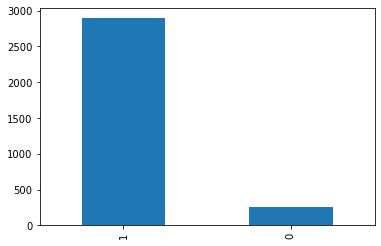

In [7]:
feedback_counts.plot(kind='bar')

In [8]:
df['feedback'].unique().sum()

1

In [9]:
count_1=0
count_0=0

for feedback in df['feedback']:
    if feedback==1:
        count_1=count_1+1
    else:
        count_0=count_0+1
print(count_1)

print(count_0)
        

2893
257


In [10]:
def to_lower(string):
    return string.lower()

In [11]:
df['verified_reviews']=df['verified_reviews'].apply(to_lower)

In [12]:
df['verified_reviews'].head()

0                                        love my echo!
1                                            loved it!
2    sometimes while playing a game, you can answer...
3    i have had a lot of fun with this thing. my 4 ...
4                                                music
Name: verified_reviews, dtype: object

In [13]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [14]:
def remove_punctuation(text):
    for i in string.punctuation:
        text=text.replace(i,"")
    return text
df['verified_reviews']=df['verified_reviews'].apply(remove_punctuation)

In [15]:
df['verified_reviews']

0                                            love my echo
1                                                loved it
2       sometimes while playing a game you can answer ...
3       i have had a lot of fun with this thing my 4 y...
4                                                   music
                              ...                        
3145      perfect for kids adults and everyone in between
3146    listening to music searching locations checkin...
3147    i do love these things i have them running my ...
3148    only complaint i have is that the sound qualit...
3149                                                 good
Name: verified_reviews, Length: 3150, dtype: object

In [16]:
pip install emoji

Note: you may need to restart the kernel to use updated packages.


In [17]:
import emoji
df['verified_reviews']=df['verified_reviews'].apply(lambda s: emoji.replace_emoji(s,''))

In [18]:
df['verified_reviews']

0                                            love my echo
1                                                loved it
2       sometimes while playing a game you can answer ...
3       i have had a lot of fun with this thing my 4 y...
4                                                   music
                              ...                        
3145      perfect for kids adults and everyone in between
3146    listening to music searching locations checkin...
3147    i do love these things i have them running my ...
3148    only complaint i have is that the sound qualit...
3149                                                 good
Name: verified_reviews, Length: 3150, dtype: object

In [19]:
from nltk.tokenize import word_tokenize
import nltk

In [20]:
import nltk
nltk.download('punkt')
  

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Vaibhav\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [21]:
df['verified_reviews'].head()

0                                         love my echo
1                                             loved it
2    sometimes while playing a game you can answer ...
3    i have had a lot of fun with this thing my 4 y...
4                                                music
Name: verified_reviews, dtype: object

In [22]:
def tokennizer(text):
    tokens=word_tokenize(text)
    return tokens
# df['verified_reviews']=df['verified_reviews'].apply(tokennizer)

In [23]:
df['tokens']=df['verified_reviews'].apply(tokennizer)

In [24]:
df['tokens']

0                                        [love, my, echo]
1                                             [loved, it]
2       [sometimes, while, playing, a, game, you, can,...
3       [i, have, had, a, lot, of, fun, with, this, th...
4                                                 [music]
                              ...                        
3145    [perfect, for, kids, adults, and, everyone, in...
3146    [listening, to, music, searching, locations, c...
3147    [i, do, love, these, things, i, have, them, ru...
3148    [only, complaint, i, have, is, that, the, soun...
3149                                               [good]
Name: tokens, Length: 3150, dtype: object

In [25]:
from nltk.corpus import stopwords

In [26]:
stopwords=set(stopwords.words('english'))

In [27]:
stopwords

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'only',
 'or',
 'other',
 'our',
 'ours',
 'ourselves',
 'out',
 'over',
 'own',
 'r

In [29]:
def remove_stop(tokens):
    for token in tokens:
        if token in stopwords:
            tokens.remove(token)
    return tokens
    

In [30]:
df['withoutstopwords']=df['tokens'].apply(remove_stop)

In [31]:
df['withoutstopwords']

0                                            [love, echo]
1                                                 [loved]
2       [sometimes, playing, game, can, answer, questi...
3       [have, a, lot, fun, this, thing, 4, yr, old, l...
4                                                 [music]
                              ...                        
3145           [perfect, kids, adults, everyone, between]
3146    [listening, music, searching, locations, check...
3147    [do, love, things, have, running, entire, home...
3148    [complaint, sound, quality, isnt, great, mostl...
3149                                               [good]
Name: withoutstopwords, Length: 3150, dtype: object

In [32]:
from nltk.stem import PorterStemmer
def stemming(tokens):
    stemmer=PorterStemmer()
    stem_tokens=[stemmer.stem(token) for token in tokens]
    return stem_tokens

In [33]:
df['stem_tokens']=df['tokens'].apply(stemming)

In [34]:
df['stem_tokens']

0                                            [love, echo]
1                                                  [love]
2       [sometim, play, game, can, answer, question, c...
3       [have, a, lot, fun, thi, thing, 4, yr, old, le...
4                                                 [music]
                              ...                        
3145              [perfect, kid, adult, everyon, between]
3146    [listen, music, search, locat, check, time, lo...
3147    [do, love, thing, have, run, entir, home, tv, ...
3148    [complaint, sound, qualiti, isnt, great, mostl...
3149                                               [good]
Name: stem_tokens, Length: 3150, dtype: object

In [37]:
import nltk
nltk.download('wordnet')
  

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Vaibhav\AppData\Roaming\nltk_data...


True

In [38]:
from nltk.stem import WordNetLemmatizer
def lemmitizer(tokens):
    lemm=WordNetLemmatizer()
    lemm_tokens=[lemm.lemmatize(token) for token in tokens]
    return tokens

In [41]:
df['lemm_tokens']=df['tokens'].apply(lemmitizer)

In [42]:
df['lemm_tokens']

0                                            [love, echo]
1                                                 [loved]
2       [sometimes, playing, game, can, answer, questi...
3       [have, a, lot, fun, this, thing, 4, yr, old, l...
4                                                 [music]
                              ...                        
3145           [perfect, kids, adults, everyone, between]
3146    [listening, music, searching, locations, check...
3147    [do, love, things, have, running, entire, home...
3148    [complaint, sound, quality, isnt, great, mostl...
3149                                               [good]
Name: lemm_tokens, Length: 3150, dtype: object

In [45]:
from sklearn.feature_extraction.text import CountVectorizer
count_vect=CountVectorizer()
reviews_vect=count_vect.fit_transform(df['verified_reviews'])

In [46]:
reviews_vect

<3150x4485 sparse matrix of type '<class 'numpy.int64'>'
	with 60899 stored elements in Compressed Sparse Row format>

In [48]:
vect_review=pd.DataFrame(reviews_vect.toarray(),columns=CountVectorizer)

TypeError: 'type' object is not iterable

In [49]:
vect_review=pd.DataFrame(data=reviews_vect)

In [50]:
vect_review

,0
0,"(0, 2394)\t1\n (0, 2582)\t1\n (0, 1313)\t1"
1,"(0, 2395)\t1\n (0, 2152)\t1"
2,"(0, 2152)\t1\n (0, 3632)\t1\n (0, 4374)\t2..."
3,"(0, 2582)\t1\n (0, 2933)\t1\n (0, 336)\t1\..."
4,"(0, 2569)\t1"
...,...
3145,"(0, 336)\t1\n (0, 2016)\t1\n (0, 1623)\t1\..."
3146,"(0, 2152)\t1\n (0, 4030)\t3\n (0, 2569)\t1..."
3147,"(0, 2394)\t2\n (0, 2582)\t4\n (0, 4462)\t3..."
3148,"(0, 2582)\t1\n (0, 1313)\t1\n (0, 2152)\t1..."


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidvect=TfidfVectorizer()
tfidf_vectors = tfidvect.fit_transform(df['verified_reviews'])

In [58]:
tfif_df=pd.DataFrame(data=tfidf_vectors.toarray(),columns=tfidvect.get_feature_names())

In [59]:
tfif_df

,072318,10,100,1000,100x,1010,1030pm,11,1100sf,1220,...,yr,yrs,yup,zero,zigbee,zonkedout,zwave,zzzz,zzzzzzz,útil
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.307379,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3145,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3146,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3148,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
